In [1]:
from tqdm.notebook import trange
import random
import numpy as np
import matplotlib.pylab as plt



def MAKEU16(a, b):
    return ((a << 8) | b)

def mul_x(v, c):
    if v & 0x8000:
        return (v << 1) ^ c
    else:
        return (v << 1)
        
def mul_x_inv(v, d):
    if v & 0x0001:
        return (v >> 1) ^ d
    else:
        return (v >> 1) 

iv = []
for k in range(10000):
    sub_iv = []
    for l in range(16):
        sub_iv.append(random.randint(0, 255))
    iv.append(sub_iv) 

     

key = [0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff,
       0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff,
       0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff,
       0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff, 0xff]


size of u (10,)
size of HW_u (10,)
size of u_hyp (10, 256)
size of HW_u_hyp (10, 256)


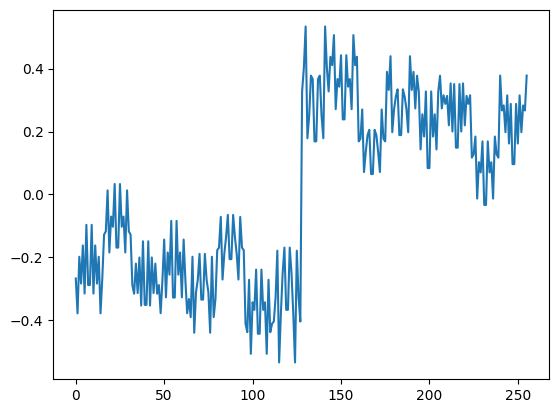

In [2]:
A1 = [0] * 16
B1 = [0] * 16
u1 = [] 
u_hyp1 = []
HW_u1 = []
HW_u_hyp1 = []

for j in range(10):
    for i in range(8):
        A1[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
        A1[i + 8] = MAKEU16(key[2 * i + 1], key[2 * i])
        B1[i] = 0x0000
        B1[i + 8] = MAKEU16(key[2 * i + 17], key[2 * i + 16]) 
   
    u1.append(mul_x(A1[0], 0x990f) ^ A1[1] ^ mul_x_inv(A1[8], 0xcc87) ^ B1[0])
print("size of u",np.shape(u1)) 

for k in u1:    
    HW_u1.append((bin(k).count("1"))) #Hamming weight of 1000 u 16 bits
print("size of HW_u",np.shape(HW_u1))
    

for j in range(10):
    sub_u_hyp1 = []
    for A1[8] in range(0, 256):
        for i in range(8):
            A1[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
            B1[i] = 0x0000
        sub_u_hyp1.append(mul_x(A1[0], 0x990f) ^ A1[1] ^ mul_x_inv(A1[8], 0xcc87) ^ B1[0])    
    u_hyp1.append(sub_u_hyp1)
print("size of u_hyp",np.shape(u_hyp1))

for m in range(len(u_hyp1)):
    sub_HW_u_hyp1 = []
    for s in range(256):
        sub_HW_u_hyp1.append(('{0:08b}'.format(u_hyp1[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp1.append(sub_HW_u_hyp1)
print("size of HW_u_hyp", np.shape(HW_u_hyp1))

samples_per_trace1 = np.shape(HW_u_hyp1)[1]
num_traces1 = np.shape(HW_u_hyp1)[0]

plt.figure()
hyp_pwr1 = np.array(HW_u1).reshape(-1,1)

traces_hyp_pwr1 = np.concatenate((HW_u_hyp1,hyp_pwr1), axis = 1)
    
correlation1 = np.corrcoef(traces_hyp_pwr1.T)
corr1 = correlation1[samples_per_trace1, :samples_per_trace1]
plt.plot(corr1)
plt.show()

In [28]:
print(corr1[240])

0.3777198357842386


size of u (50,)
size of HW_u (50,)
size of u_hyp (50, 256)
size of HW_u_hyp (50, 256)


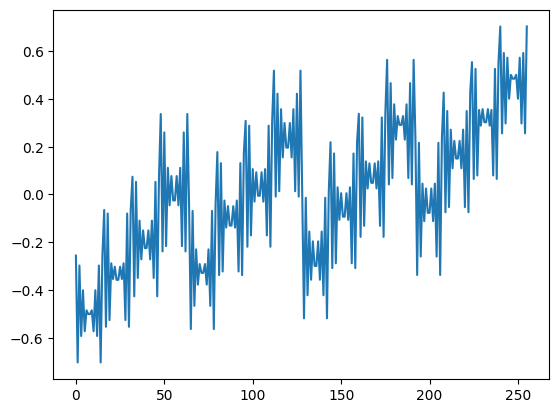

In [3]:
A2 = [0] * 16
B2 = [0] * 16
u2 = [] 
u_hyp2 = []
HW_u2 = []
HW_u_hyp2 = []

for j in range(50):
    for i in range(8):
        A2[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
        A2[i + 8] = MAKEU16(key[2 * i + 1], key[2 * i])
        B2[i] = 0x0000
        B2[i + 8] = MAKEU16(key[2 * i + 17], key[2 * i + 16]) 
   
    u2.append(mul_x(A2[0], 0x990f) ^ A2[1] ^ mul_x_inv(A2[8], 0xcc87) ^ B2[0])
print("size of u",np.shape(u2)) 

for k in u2:    
    HW_u2.append((bin(k).count("1"))) #Hamming weight of 1000 u 16 bits
print("size of HW_u",np.shape(HW_u2))
    

for j in range(50):
    sub_u_hyp2 = []
    for A2[8] in range(0, 256):
        for i in range(8):
            A2[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
            B2[i] = 0x0000
        sub_u_hyp2.append(mul_x(A2[0], 0x990f) ^ A2[1] ^ mul_x_inv(A2[8], 0xcc87) ^ B2[0])    
    u_hyp2.append(sub_u_hyp2)
print("size of u_hyp",np.shape(u_hyp2))

for m in range(len(u_hyp2)):
    sub_HW_u_hyp2 = []
    for s in range(256):
        sub_HW_u_hyp2.append(('{0:08b}'.format(u_hyp2[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp2.append(sub_HW_u_hyp2)
print("size of HW_u_hyp", np.shape(HW_u_hyp2))

samples_per_trace2 = np.shape(HW_u_hyp2)[1]
num_traces2 = np.shape(HW_u_hyp2)[0]

plt.figure()
hyp_pwr2 = np.array(HW_u2).reshape(-1,1)

traces_hyp_pwr2 = np.concatenate((HW_u_hyp2,hyp_pwr2), axis = 1)
    
correlation2 = np.corrcoef(traces_hyp_pwr2.T)
corr2 = correlation2[samples_per_trace2, :samples_per_trace2]
plt.plot(corr2)
plt.show()

In [31]:
print(corr2[255])

0.703214500392048


size of u (75,)
size of HW_u (75,)
size of u_hyp (75, 256)
size of HW_u_hyp (75, 256)


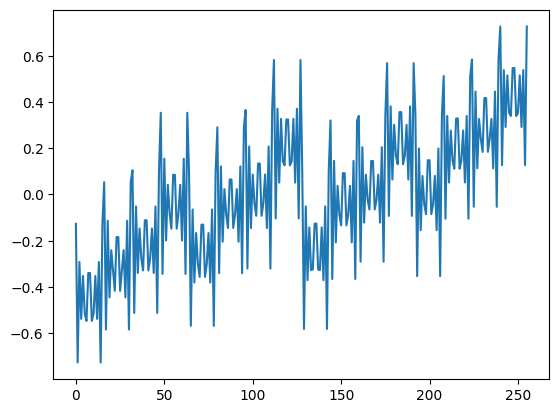

In [8]:
A3 = [0] * 16
B3 = [0] * 16
u3 = [] 
u_hyp3 = []
HW_u3 = []
HW_u_hyp3 = []

for j in range(75):
    for i in range(8):
        A3[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
        A3[i + 8] = MAKEU16(key[2 * i + 1], key[2 * i])
        B3[i] = 0x0000
        B3[i + 8] = MAKEU16(key[2 * i + 17], key[2 * i + 16]) 
   
    u3.append(mul_x(A3[0], 0x990f) ^ A3[1] ^ mul_x_inv(A3[8], 0xcc87) ^ B3[0])
print("size of u",np.shape(u3)) 

for k in u3:    
    HW_u3.append((bin(k).count("1"))) #Hamming weight of 1000 u 16 bits
print("size of HW_u",np.shape(HW_u3))
    

for j in range(75):
    sub_u_hyp3 = []
    for A3[8] in range(0, 256):
        for i in range(8):
            A3[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
            B3[i] = 0x0000
        sub_u_hyp3.append(mul_x(A3[0], 0x990f) ^ A3[1] ^ mul_x_inv(A3[8], 0xcc87) ^ B3[0])    
    u_hyp3.append(sub_u_hyp3)
print("size of u_hyp",np.shape(u_hyp3))

for m in range(len(u_hyp3)):
    sub_HW_u_hyp3 = []
    for s in range(256):
        sub_HW_u_hyp3.append(('{0:08b}'.format(u_hyp3[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp3.append(sub_HW_u_hyp3)
print("size of HW_u_hyp", np.shape(HW_u_hyp3))

samples_per_trace3 = np.shape(HW_u_hyp3)[1]
num_traces3 = np.shape(HW_u_hyp3)[0]

plt.figure()
hyp_pwr3 = np.array(HW_u3).reshape(-1,1)

traces_hyp_pwr3 = np.concatenate((HW_u_hyp3,hyp_pwr3), axis = 1)
    
correlation3 = np.corrcoef(traces_hyp_pwr3.T)
corr3 = correlation3[samples_per_trace3, :samples_per_trace3]
plt.plot(corr3)
plt.show()

size of u (100,)
size of HW_u (100,)
size of u_hyp (100, 256)
size of HW_u_hyp (100, 256)


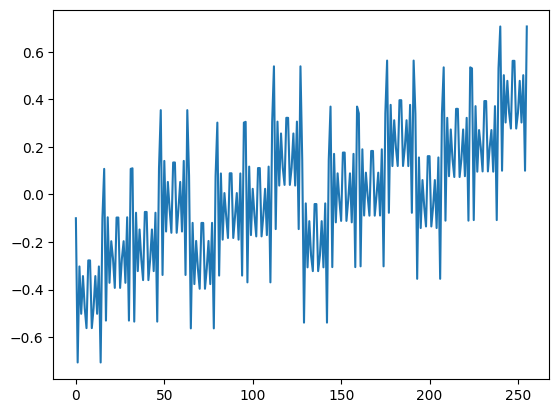

In [10]:
A4 = [0] * 16
B4 = [0] * 16
u4 = [] 
u_hyp4 = []
HW_u4 = []
HW_u_hyp4 = []

for j in range(100):
    for i in range(8):
        A4[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
        A4[i + 8] = MAKEU16(key[2 * i + 1], key[2 * i])
        B4[i] = 0x0000
        B4[i + 8] = MAKEU16(key[2 * i + 17], key[2 * i + 16]) 
   
    u4.append(mul_x(A4[0], 0x990f) ^ A4[1] ^ mul_x_inv(A4[8], 0xcc87) ^ B4[0])
print("size of u",np.shape(u4)) 

for k in u4:    
    HW_u4.append((bin(k).count("1"))) #Hamming weight of 1000 u 16 bits
print("size of HW_u",np.shape(HW_u4))
    

for j in range(100):
    sub_u_hyp4 = []
    for A4[8] in range(0, 256):
        for i in range(8):
            A4[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
            B4[i] = 0x0000
        sub_u_hyp4.append(mul_x(A4[0], 0x990f) ^ A4[1] ^ mul_x_inv(A4[8], 0xcc87) ^ B4[0])    
    u_hyp4.append(sub_u_hyp4)
print("size of u_hyp",np.shape(u_hyp4))

for m in range(len(u_hyp4)):
    sub_HW_u_hyp4 = []
    for s in range(256):
        sub_HW_u_hyp4.append(('{0:08b}'.format(u_hyp4[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp4.append(sub_HW_u_hyp4)
print("size of HW_u_hyp", np.shape(HW_u_hyp4))

samples_per_trace4 = np.shape(HW_u_hyp4)[1]
num_traces4 = np.shape(HW_u_hyp4)[0]

plt.figure()
hyp_pwr4 = np.array(HW_u4).reshape(-1,1)

traces_hyp_pwr4 = np.concatenate((HW_u_hyp4,hyp_pwr4), axis = 1)
    
correlation4 = np.corrcoef(traces_hyp_pwr4.T)
corr4 = correlation4[samples_per_trace4, :samples_per_trace4]
plt.plot(corr4)
plt.show()

size of u (200,)
size of HW_u (200,)
size of u_hyp (200, 256)
size of HW_u_hyp (200, 256)


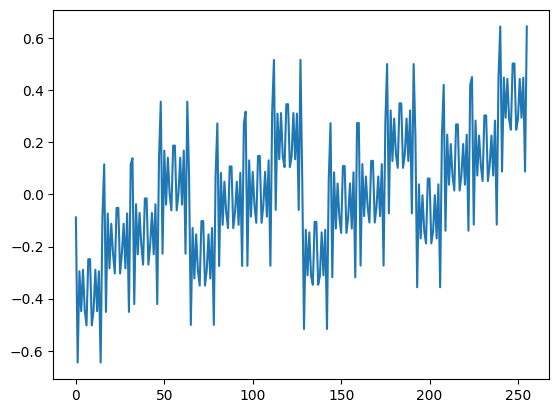

In [12]:
A5 = [0] * 16
B5 = [0] * 16
u5 = [] 
u_hyp5 = []
HW_u5 = []
HW_u_hyp5 = []

for j in range(200):
    for i in range(8):
        A5[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
        A5[i + 8] = MAKEU16(key[2 * i + 1], key[2 * i])
        B5[i] = 0x0000
        B5[i + 8] = MAKEU16(key[2 * i + 17], key[2 * i + 16]) 
   
    u5.append(mul_x(A5[0], 0x990f) ^ A5[1] ^ mul_x_inv(A5[8], 0xcc87) ^ B5[0])
print("size of u",np.shape(u5)) 

for k in u5:    
    HW_u5.append((bin(k).count("1"))) #Hamming weight of 1000 u 16 bits
print("size of HW_u",np.shape(HW_u5))
    

for j in range(200):
    sub_u_hyp5 = []
    for A5[8] in range(0, 256):
        for i in range(8):
            A5[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
            B5[i] = 0x0000
        sub_u_hyp5.append(mul_x(A5[0], 0x990f) ^ A5[1] ^ mul_x_inv(A5[8], 0xcc87) ^ B5[0])    
    u_hyp5.append(sub_u_hyp5)
print("size of u_hyp",np.shape(u_hyp5))

for m in range(len(u_hyp5)):
    sub_HW_u_hyp5 = []
    for s in range(256):
        sub_HW_u_hyp5.append(('{0:08b}'.format(u_hyp5[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp5.append(sub_HW_u_hyp5)
print("size of HW_u_hyp", np.shape(HW_u_hyp5))

samples_per_trace5 = np.shape(HW_u_hyp5)[1]
num_traces5 = np.shape(HW_u_hyp5)[0]

plt.figure()
hyp_pwr5 = np.array(HW_u5).reshape(-1,1)

traces_hyp_pwr5 = np.concatenate((HW_u_hyp5,hyp_pwr5), axis = 1)
    
correlation5 = np.corrcoef(traces_hyp_pwr5.T)
corr5 = correlation5[samples_per_trace5, :samples_per_trace5]
plt.plot(corr5)
plt.show()

size of u (500,)
size of HW_u (500,)
size of u_hyp (500, 256)
size of HW_u_hyp (500, 256)


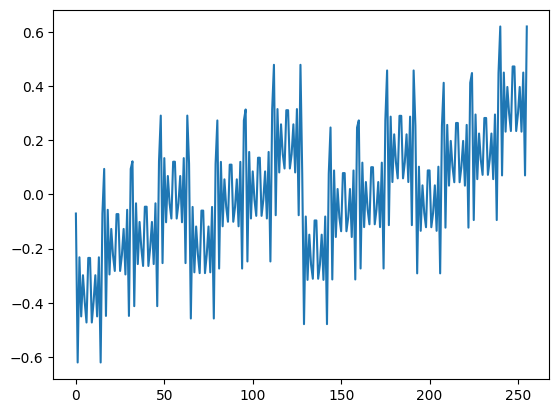

In [15]:
A6 = [0] * 16
B6 = [0] * 16
u6 = [] 
u_hyp6 = []
HW_u6 = []
HW_u_hyp6 = []

for j in range(500):
    for i in range(8):
        A6[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
        A6[i + 8] = MAKEU16(key[2 * i + 1], key[2 * i])
        B6[i] = 0x0000
        B6[i + 8] = MAKEU16(key[2 * i + 17], key[2 * i + 16]) 
   
    u6.append(mul_x(A6[0], 0x990f) ^ A6[1] ^ mul_x_inv(A6[8], 0xcc87) ^ B6[0])
print("size of u",np.shape(u6)) 

for k in u6:    
    HW_u6.append((bin(k).count("1"))) #Hamming weight of 1000 u 16 bits
print("size of HW_u",np.shape(HW_u6))
    

for j in range(500):
    sub_u_hyp6 = []
    for A6[8] in range(0, 256):
        for i in range(8):
            A6[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
            B6[i] = 0x0000
        sub_u_hyp6.append(mul_x(A6[0], 0x990f) ^ A6[1] ^ mul_x_inv(A6[8], 0xcc87) ^ B6[0])    
    u_hyp6.append(sub_u_hyp6)
print("size of u_hyp",np.shape(u_hyp6))

for m in range(len(u_hyp6)):
    sub_HW_u_hyp6 = []
    for s in range(256):
        sub_HW_u_hyp6.append(('{0:08b}'.format(u_hyp6[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp6.append(sub_HW_u_hyp6)
print("size of HW_u_hyp", np.shape(HW_u_hyp6))

samples_per_trace6 = np.shape(HW_u_hyp6)[1]
num_traces6 = np.shape(HW_u_hyp6)[0]

plt.figure()
hyp_pwr6 = np.array(HW_u6).reshape(-1,1)

traces_hyp_pwr6 = np.concatenate((HW_u_hyp6,hyp_pwr6), axis = 1)
    
correlation6 = np.corrcoef(traces_hyp_pwr6.T)
corr6 = correlation6[samples_per_trace6, :samples_per_trace6]
plt.plot(corr6)
plt.show()

size of u (1000,)
size of HW_u (1000,)
size of u_hyp (1000, 256)
size of HW_u_hyp (1000, 256)


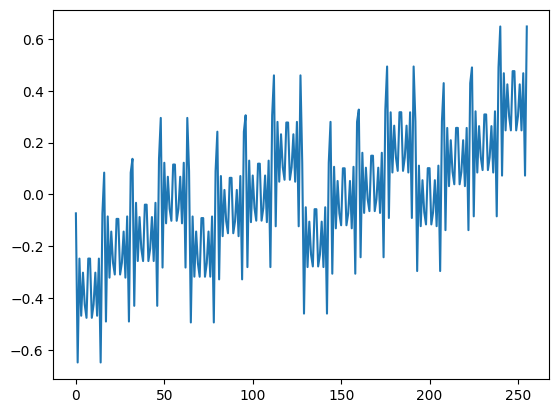

In [17]:
A7 = [0] * 16
B7 = [0] * 16
u7 = [] 
u_hyp7 = []
HW_u7 = []
HW_u_hyp7 = []

for j in range(1000):
    for i in range(8):
        A7[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
        A7[i + 8] = MAKEU16(key[2 * i + 1], key[2 * i])
        B7[i] = 0x0000
        B7[i + 8] = MAKEU16(key[2 * i + 17], key[2 * i + 16]) 
   
    u7.append(mul_x(A7[0], 0x990f) ^ A7[1] ^ mul_x_inv(A7[8], 0xcc87) ^ B7[0])
print("size of u",np.shape(u7)) 

for k in u7:    
    HW_u7.append((bin(k).count("1"))) #Hamming weight of 1000 u 16 bits
print("size of HW_u",np.shape(HW_u7))
    

for j in range(1000):
    sub_u_hyp7 = []
    for A7[8] in range(0, 256):
        for i in range(8):
            A7[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
            B7[i] = 0x0000
        sub_u_hyp7.append(mul_x(A7[0], 0x990f) ^ A7[1] ^ mul_x_inv(A7[8], 0xcc87) ^ B7[0])    
    u_hyp7.append(sub_u_hyp7)
print("size of u_hyp",np.shape(u_hyp7))

for m in range(len(u_hyp7)):
    sub_HW_u_hyp7 = []
    for s in range(256):
        sub_HW_u_hyp7.append(('{0:08b}'.format(u_hyp7[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp7.append(sub_HW_u_hyp7)
print("size of HW_u_hyp", np.shape(HW_u_hyp7))

samples_per_trace7 = np.shape(HW_u_hyp7)[1]
num_traces7 = np.shape(HW_u_hyp7)[0]

plt.figure()
hyp_pwr7 = np.array(HW_u7).reshape(-1,1)

traces_hyp_pwr7 = np.concatenate((HW_u_hyp7,hyp_pwr7), axis = 1)
    
correlation7 = np.corrcoef(traces_hyp_pwr7.T)
corr7 = correlation7[samples_per_trace7, :samples_per_trace7]
plt.plot(corr7)
plt.show()

size of u (5000,)
size of HW_u (5000,)
size of u_hyp (5000, 256)
size of HW_u_hyp (5000, 256)


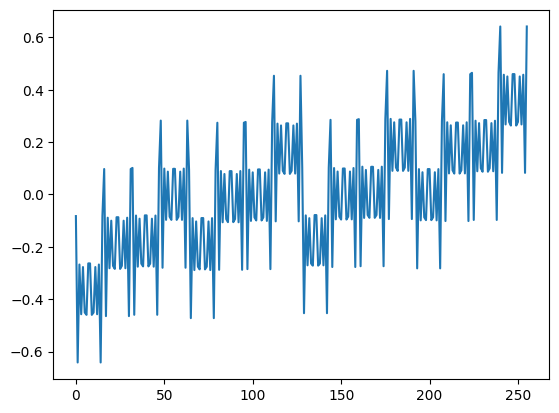

In [19]:
A8 = [0] * 16
B8 = [0] * 16
u8 = [] 
u_hyp8 = []
HW_u8 = []
HW_u_hyp8 = []

for j in range(5000):
    for i in range(8):
        A8[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
        A8[i + 8] = MAKEU16(key[2 * i + 1], key[2 * i])
        B8[i] = 0x0000
        B8[i + 8] = MAKEU16(key[2 * i + 17], key[2 * i + 16]) 
   
    u8.append(mul_x(A8[0], 0x990f) ^ A8[1] ^ mul_x_inv(A8[8], 0xcc87) ^ B8[0])
print("size of u",np.shape(u8)) 

for k in u8:    
    HW_u8.append((bin(k).count("1"))) #Hamming weight of 1000 u 16 bits
print("size of HW_u",np.shape(HW_u8))
    

for j in range(5000):
    sub_u_hyp8 = []
    for A8[8] in range(0, 256):
        for i in range(8):
            A8[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
            B8[i] = 0x0000
        sub_u_hyp8.append(mul_x(A8[0], 0x990f) ^ A8[1] ^ mul_x_inv(A8[8], 0xcc87) ^ B8[0])    
    u_hyp8.append(sub_u_hyp8)
print("size of u_hyp",np.shape(u_hyp8))

for m in range(len(u_hyp8)):
    sub_HW_u_hyp8 = []
    for s in range(256):
        sub_HW_u_hyp8.append(('{0:08b}'.format(u_hyp8[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp8.append(sub_HW_u_hyp8)
print("size of HW_u_hyp", np.shape(HW_u_hyp8))

samples_per_trace8 = np.shape(HW_u_hyp8)[1]
num_traces8 = np.shape(HW_u_hyp8)[0]

plt.figure()
hyp_pwr8 = np.array(HW_u8).reshape(-1,1)

traces_hyp_pwr8 = np.concatenate((HW_u_hyp8,hyp_pwr8), axis = 1)
    
correlation8 = np.corrcoef(traces_hyp_pwr8.T)
corr8 = correlation8[samples_per_trace8, :samples_per_trace8]
plt.plot(corr8)
plt.show()

size of u (10000,)
size of HW_u (10000,)
size of u_hyp (10000, 256)
size of HW_u_hyp (10000, 256)


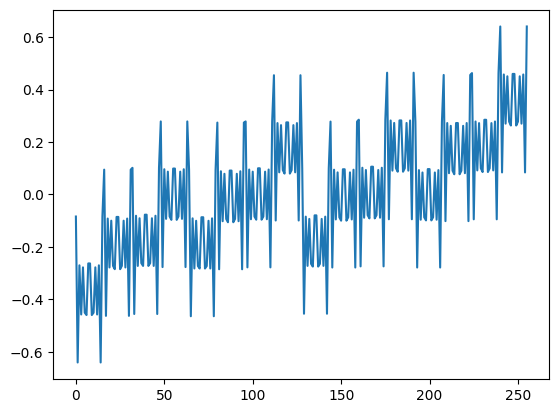

In [21]:
A9 = [0] * 16
B9 = [0] * 16
u9 = [] 
u_hyp9 = []
HW_u9 = []
HW_u_hyp9 = []

for j in range(10000):
    for i in range(8):
        A9[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
        A9[i + 8] = MAKEU16(key[2 * i + 1], key[2 * i])
        B9[i] = 0x0000
        B9[i + 8] = MAKEU16(key[2 * i + 17], key[2 * i + 16]) 
   
    u9.append(mul_x(A9[0], 0x990f) ^ A9[1] ^ mul_x_inv(A9[8], 0xcc87) ^ B9[0])
print("size of u",np.shape(u9)) 

for k in u9:    
    HW_u9.append((bin(k).count("1"))) #Hamming weight of 1000 u 16 bits
print("size of HW_u",np.shape(HW_u9))
    

for j in range(10000):
    sub_u_hyp9 = []
    for A9[8] in range(0, 256):
        for i in range(8):
            A9[i] = MAKEU16(iv[j][2 * i + 1], iv[j][2 * i])
            B9[i] = 0x0000
        sub_u_hyp9.append(mul_x(A9[0], 0x990f) ^ A9[1] ^ mul_x_inv(A9[8], 0xcc87) ^ B9[0])    
    u_hyp9.append(sub_u_hyp9)
print("size of u_hyp",np.shape(u_hyp9))

for m in range(len(u_hyp9)):
    sub_HW_u_hyp9 = []
    for s in range(256):
        sub_HW_u_hyp9.append(('{0:08b}'.format(u_hyp9[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp9.append(sub_HW_u_hyp9)
print("size of HW_u_hyp", np.shape(HW_u_hyp9))

samples_per_trace9 = np.shape(HW_u_hyp9)[1]
num_traces9 = np.shape(HW_u_hyp9)[0]

plt.figure()
hyp_pwr9 = np.array(HW_u9).reshape(-1,1)

traces_hyp_pwr9 = np.concatenate((HW_u_hyp9,hyp_pwr9), axis = 1)
    
correlation9 = np.corrcoef(traces_hyp_pwr9.T)
corr9 = correlation9[samples_per_trace9, :samples_per_trace9]
plt.plot(corr9)
plt.show()

In [23]:
corr = np.array([corr1, corr2, corr3, corr4, corr5, corr6, corr7, corr8, corr9])
print(np.shape(corr))

(9, 256)


In [32]:
sa=[0.3777198357842386,0.703214500392048]
for l in range(2,9):
    sa.append(max(corr[l]))
print(sa) 

[0.3777198357842386, 0.703214500392048, 0.7267225288772856, 0.7066730523808505, 0.6451219325692497, 0.6210088496079358, 0.648065649184099, 0.641790662116964, 0.6406924497341856]


In [33]:
sm=[-0.3777198357842386,-0.703214500392048]
for l in range(2,9):
    sm.append(min(corr[l]))
print(sm)   

[-0.3777198357842386, -0.703214500392048, -0.7267225288772856, -0.7066730523808505, -0.6451219325692497, -0.6210088496079358, -0.648065649184099, -0.641790662116964, -0.6406924497341856]


In [34]:
num = np.array([10, 50, 75, 100, 200, 500, 1000, 5000, 10000])

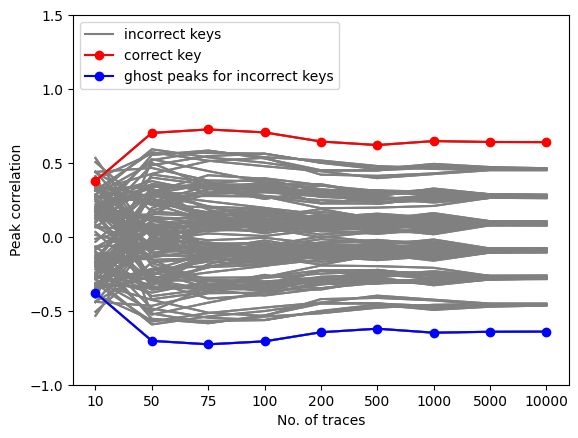

In [43]:
y=[0,1,2,3,4,5,6,7,8]
x = range(len(num-1))
fig, ax = plt.subplots()
ax.plot(x,corr, color = 'grey')
ax.plot(y,sm, color = 'grey',label="incorrect keys")
ax.plot(y,sa, marker ='o', color = 'red',label="correct key")
ax.plot(y,sm, marker = 'o', color = 'blue',label="ghost peaks for incorrect keys")
leg = ax.legend(loc ="upper left");
plt.xlabel('No. of traces')
plt.ylabel('Peak correlation')
plt.xticks(x, num)
plt.ylim([-1,1.5])
plt.savefig('mtd_captured.svg')
plt.show()